# Comparative Analysis: 2025-11-07 vs 2025-11-19
## Dewar 1m - FBG and RTD Sensor Comparison

This notebook compares:
- FBG wavelength variations (Δλ vs time) between both days
- RTD temperature variations (ΔT vs time) between both days
- Sensitivity comparison (fm/mK)
- Inter-sensor offsets for FBG sensors

**Analysis focus**: Sensor 5 as reference

In [1]:
# ========================================================================
# Import Libraries
# ========================================================================

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import datetime
from matplotlib.dates import DateFormatter, MinuteLocator

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ========================================================================
# Load Data from Both Days
# ========================================================================

# --- Day 1: 2025-11-07 ---
file_07_11 = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(file_07_11) as f:
    peak_data_07 = f["peak"].arrays(library="np")
    temp_data_07 = f["temp"].arrays(library="np")

# --- Day 2: 2025-11-19 ---
file_19_11 = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251119.root"
with uproot.open(file_19_11) as f:
    peak_data_19 = f["peak"].arrays(library="np")
    temp_data_19 = f["temp"].arrays(library="np")

print("Data loaded successfully!")
print(f"07/11 - Peak entries: {len(peak_data_07['t'])}, Temp entries: {len(temp_data_07['t'])}")
print(f"19/11 - Peak entries: {len(peak_data_19['t'])}, Temp entries: {len(temp_data_19['t'])}")

Data loaded successfully!
07/11 - Peak entries: 2099000, Temp entries: 12490
19/11 - Peak entries: 7553875, Temp entries: 20554


In [3]:
# ========================================================================
# Process Day 1: 2025-11-07 (14:00 - 18:00)
# ========================================================================

sensor5_idx = 4  # 0-based index for sensor 5

# --- Extract Sensor 5 data ---
lambdaB_pol1_07 = peak_data_07["wav"][:, 0, sensor5_idx]
lambdaB_pol2_07 = peak_data_07["wav"][:, 1, sensor5_idx]
lambdaB_07 = (lambdaB_pol1_07 + lambdaB_pol2_07) / 2.0
temp_07 = temp_data_07["temp"][:, sensor5_idx]

# --- Timestamps with +2h correction for FBG ---
peak_times_07 = pd.to_datetime(peak_data_07["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_times_07 = pd.to_datetime(temp_data_07["t"], unit='s')

# --- Time window ---
start_07 = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_07 = datetime.datetime(2025, 11, 7, 18, 0, 0)

# --- Filter ---
mask_peak_07 = (peak_times_07 >= start_07) & (peak_times_07 <= end_07)
mask_temp_07 = (temp_times_07 >= start_07) & (temp_times_07 <= end_07)

# --- Create DataFrames ---
df_peak_07 = pd.DataFrame({
    "lambdaB_nm": lambdaB_07[mask_peak_07] * 1e9
}, index=peak_times_07[mask_peak_07])

df_temp_07 = pd.DataFrame({
    "temp_K": temp_07[mask_temp_07]
}, index=temp_times_07[mask_temp_07])

# --- Resample to 1-minute bins ---
peak_07_binned = df_peak_07.resample("1min").mean()
temp_07_binned = df_temp_07.resample("1min").mean()

# --- Convert to fm and mK ---
peak_07_binned["lambdaB_fm"] = peak_07_binned["lambdaB_nm"] * 1e6
temp_07_binned["temp_mK"] = temp_07_binned["temp_K"] * 1e3

# --- Calculate Δλ and ΔT (relative to first point) ---
lambda_ref_07 = peak_07_binned["lambdaB_fm"].iloc[0]
temp_ref_07 = temp_07_binned["temp_mK"].iloc[0]

peak_07_binned["delta_lambda_fm"] = peak_07_binned["lambdaB_fm"] - lambda_ref_07
temp_07_binned["delta_temp_mK"] = temp_07_binned["temp_mK"] - temp_ref_07

print(f"Day 07/11 processed: {len(peak_07_binned)} FBG points, {len(temp_07_binned)} RTD points")
print(f"  Δλ range: {peak_07_binned['delta_lambda_fm'].min():.2f} to {peak_07_binned['delta_lambda_fm'].max():.2f} fm")
print(f"  ΔT range: {temp_07_binned['delta_temp_mK'].min():.2f} to {temp_07_binned['delta_temp_mK'].max():.2f} mK")

Day 07/11 processed: 185 FBG points, 184 RTD points
  Δλ range: -4145.63 to 1530.99 fm
  ΔT range: -20.70 to 79.45 mK


In [4]:
# ========================================================================
# Process Day 2: 2025-11-19 (17:30 - 22:00)
# ========================================================================

# --- Extract Sensor 5 data ---
lambdaB_pol1_19 = peak_data_19["wav"][:, 0, sensor5_idx]
lambdaB_pol2_19 = peak_data_19["wav"][:, 1, sensor5_idx]
lambdaB_19 = (lambdaB_pol1_19 + lambdaB_pol2_19) / 2.0
temp_19 = temp_data_19["temp"][:, sensor5_idx]

# --- Timestamps with +2h correction for FBG ---
peak_times_19 = pd.to_datetime(peak_data_19["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_times_19 = pd.to_datetime(temp_data_19["t"], unit='s')

# --- Time window ---
start_19 = datetime.datetime(2025, 11, 19, 17, 30, 0)
end_19 = datetime.datetime(2025, 11, 19, 22, 0, 0)

# --- Filter ---
mask_peak_19 = (peak_times_19 >= start_19) & (peak_times_19 <= end_19)
mask_temp_19 = (temp_times_19 >= start_19) & (temp_times_19 <= end_19)

# --- Create DataFrames ---
df_peak_19 = pd.DataFrame({
    "lambdaB_nm": lambdaB_19[mask_peak_19] * 1e9
}, index=peak_times_19[mask_peak_19])

df_temp_19 = pd.DataFrame({
    "temp_K": temp_19[mask_temp_19]
}, index=temp_times_19[mask_temp_19])

# --- Resample to 1-minute bins ---
peak_19_binned = df_peak_19.resample("1min").mean()
temp_19_binned = df_temp_19.resample("1min").mean()

# --- Convert to fm and mK ---
peak_19_binned["lambdaB_fm"] = peak_19_binned["lambdaB_nm"] * 1e6
temp_19_binned["temp_mK"] = temp_19_binned["temp_K"] * 1e3

# --- Calculate Δλ and ΔT (relative to first point) ---
lambda_ref_19 = peak_19_binned["lambdaB_fm"].iloc[0]
temp_ref_19 = temp_19_binned["temp_mK"].iloc[0]

peak_19_binned["delta_lambda_fm"] = peak_19_binned["lambdaB_fm"] - lambda_ref_19
temp_19_binned["delta_temp_mK"] = temp_19_binned["temp_mK"] - temp_ref_19

print(f"Day 19/11 processed: {len(peak_19_binned)} FBG points, {len(temp_19_binned)} RTD points")
print(f"  Δλ range: {peak_19_binned['delta_lambda_fm'].min():.2f} to {peak_19_binned['delta_lambda_fm'].max():.2f} fm")
print(f"  ΔT range: {temp_19_binned['delta_temp_mK'].min():.2f} to {temp_19_binned['delta_temp_mK'].max():.2f} mK")

Day 19/11 processed: 270 FBG points, 270 RTD points
  Δλ range: -2707.89 to 223.92 fm
  ΔT range: -91.89 to 22.48 mK


In [5]:
# ========================================================================
# Create Relative Time Axis (minutes from start)
# ========================================================================

# Convert timestamps to minutes from start for easier comparison
peak_07_binned["minutes"] = (peak_07_binned.index - peak_07_binned.index[0]).total_seconds() / 60
temp_07_binned["minutes"] = (temp_07_binned.index - temp_07_binned.index[0]).total_seconds() / 60

peak_19_binned["minutes"] = (peak_19_binned.index - peak_19_binned.index[0]).total_seconds() / 60
temp_19_binned["minutes"] = (temp_19_binned.index - temp_19_binned.index[0]).total_seconds() / 60

print("Relative time axis created (minutes from start)")
print(f"  07/11: 0 to {peak_07_binned['minutes'].max():.1f} minutes")
print(f"  19/11: 0 to {peak_19_binned['minutes'].max():.1f} minutes")

Relative time axis created (minutes from start)
  07/11: 0 to 184.0 minutes
  19/11: 0 to 269.0 minutes


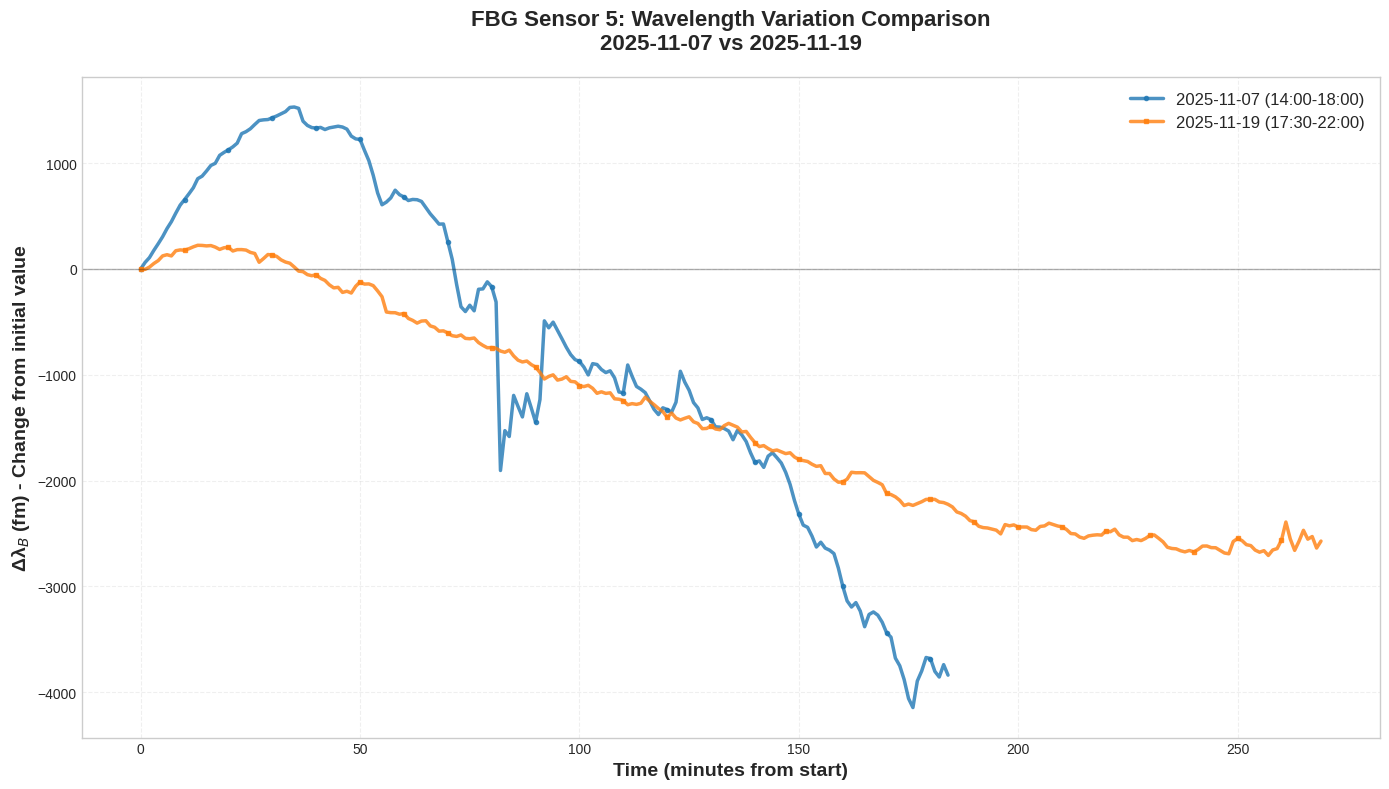

FBG WAVELENGTH VARIATION COMPARISON

07/11 (14:00-18:00):
  Total Δλ variation: 5676.62 fm
  Range: -4145.63 to 1530.99 fm

19/11 (17:30-22:00):
  Total Δλ variation: 2931.80 fm
  Range: -2707.89 to 223.92 fm


In [6]:
# ========================================================================
# COMPARATIVE PLOT 1: Δλ vs Time (Both Days)
# ========================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# --- Plot both days ---
ax.plot(peak_07_binned["minutes"], peak_07_binned["delta_lambda_fm"], 
        color='#1f77b4', linewidth=2.5, alpha=0.8, label='2025-11-07 (14:00-18:00)', marker='o', markersize=3, markevery=10)

ax.plot(peak_19_binned["minutes"], peak_19_binned["delta_lambda_fm"], 
        color='#ff7f0e', linewidth=2.5, alpha=0.8, label='2025-11-19 (17:30-22:00)', marker='s', markersize=3, markevery=10)

# --- Formatting ---
ax.set_xlabel('Time (minutes from start)', fontsize=14, fontweight='bold')
ax.set_ylabel('Δλ$_B$ (fm) - Change from initial value', fontsize=14, fontweight='bold')
ax.set_title('FBG Sensor 5: Wavelength Variation Comparison\n2025-11-07 vs 2025-11-19', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='best', framealpha=0.95, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistics ---
print("="*70)
print("FBG WAVELENGTH VARIATION COMPARISON")
print("="*70)
print(f"\n07/11 (14:00-18:00):")
print(f"  Total Δλ variation: {peak_07_binned['delta_lambda_fm'].max() - peak_07_binned['delta_lambda_fm'].min():.2f} fm")
print(f"  Range: {peak_07_binned['delta_lambda_fm'].min():.2f} to {peak_07_binned['delta_lambda_fm'].max():.2f} fm")

print(f"\n19/11 (17:30-22:00):")
print(f"  Total Δλ variation: {peak_19_binned['delta_lambda_fm'].max() - peak_19_binned['delta_lambda_fm'].min():.2f} fm")
print(f"  Range: {peak_19_binned['delta_lambda_fm'].min():.2f} to {peak_19_binned['delta_lambda_fm'].max():.2f} fm")
print("="*70)

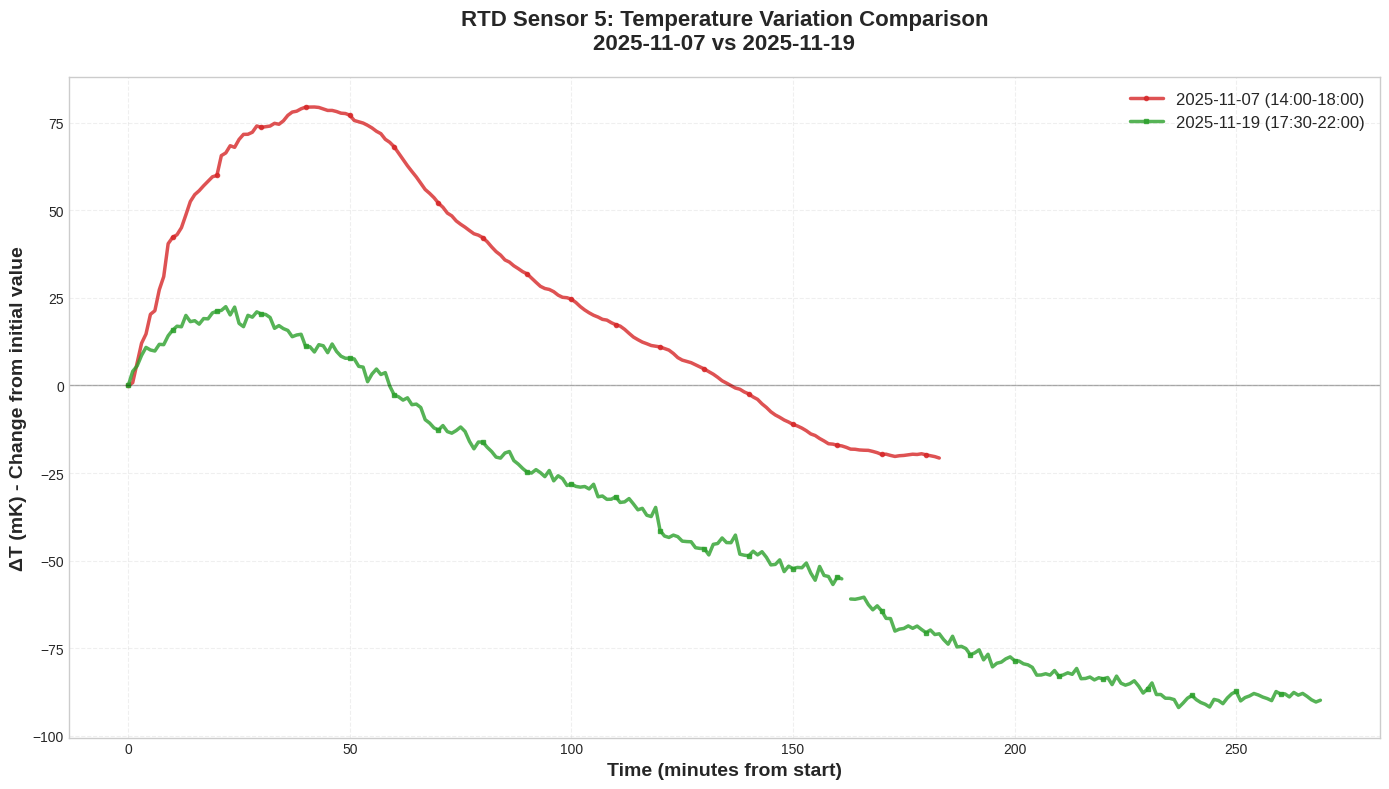

RTD TEMPERATURE VARIATION COMPARISON

07/11 (14:00-18:00):
  Total ΔT variation: 100.15 mK
  Range: -20.70 to 79.45 mK

19/11 (17:30-22:00):
  Total ΔT variation: 114.38 mK
  Range: -91.89 to 22.48 mK


In [7]:
# ========================================================================
# COMPARATIVE PLOT 2: ΔT vs Time (Both Days)
# ========================================================================

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# --- Plot both days ---
ax.plot(temp_07_binned["minutes"], temp_07_binned["delta_temp_mK"], 
        color='#d62728', linewidth=2.5, alpha=0.8, label='2025-11-07 (14:00-18:00)', marker='o', markersize=3, markevery=10)

ax.plot(temp_19_binned["minutes"], temp_19_binned["delta_temp_mK"], 
        color='#2ca02c', linewidth=2.5, alpha=0.8, label='2025-11-19 (17:30-22:00)', marker='s', markersize=3, markevery=10)

# --- Formatting ---
ax.set_xlabel('Time (minutes from start)', fontsize=14, fontweight='bold')
ax.set_ylabel('ΔT (mK) - Change from initial value', fontsize=14, fontweight='bold')
ax.set_title('RTD Sensor 5: Temperature Variation Comparison\n2025-11-07 vs 2025-11-19', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='best', framealpha=0.95, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistics ---
print("="*70)
print("RTD TEMPERATURE VARIATION COMPARISON")
print("="*70)
print(f"\n07/11 (14:00-18:00):")
print(f"  Total ΔT variation: {temp_07_binned['delta_temp_mK'].max() - temp_07_binned['delta_temp_mK'].min():.2f} mK")
print(f"  Range: {temp_07_binned['delta_temp_mK'].min():.2f} to {temp_07_binned['delta_temp_mK'].max():.2f} mK")

print(f"\n19/11 (17:30-22:00):")
print(f"  Total ΔT variation: {temp_19_binned['delta_temp_mK'].max() - temp_19_binned['delta_temp_mK'].min():.2f} mK")
print(f"  Range: {temp_19_binned['delta_temp_mK'].min():.2f} to {temp_19_binned['delta_temp_mK'].max():.2f} mK")
print("="*70)

In [8]:
# ========================================================================
# SENSITIVITY COMPARISON (fm/mK)
# ========================================================================

# Calculate sensitivity for each day using linear regression

def calculate_sensitivity(peak_df, temp_df):
    """Calculate sensitivity using manual linear regression with aligned data"""
    # Merge DataFrames on common time indices (inner join ensures alignment)
    combined = pd.merge(
        peak_df[["delta_lambda_fm"]], 
        temp_df[["delta_temp_mK"]], 
        left_index=True, 
        right_index=True, 
        how='inner'
    )
    
    # Extract aligned arrays
    lambda_data = combined["delta_lambda_fm"].values
    temp_data = combined["delta_temp_mK"].values
    
    # Remove NaN values
    valid_mask = ~(np.isnan(temp_data) | np.isnan(lambda_data))
    x = temp_data[valid_mask]
    y = lambda_data[valid_mask]
    
    if len(x) < 2:
        return 0.0, 0.0, 0
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    
    if denominator > 1e-6:
        slope = numerator / denominator
        intercept = y_mean - slope * x_mean
        
        # R-squared
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y_mean)**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 1e-6 else 0.0
    else:
        slope = 0.0
        intercept = 0.0
        r_squared = 0.0
    
    return slope, intercept, r_squared, len(x)

# --- Day 07/11 ---
sens_07, intercept_07, r2_07, n_07 = calculate_sensitivity(peak_07_binned, temp_07_binned)

# --- Day 19/11 ---
sens_19, intercept_19, r2_19, n_19 = calculate_sensitivity(peak_19_binned, temp_19_binned)

print("="*70)
print("SENSITIVITY COMPARISON (Δλ/ΔT)")
print("="*70)
print(f"\n07/11 - Time window: 14:00-18:00 UTC (240 minutes)")
print(f"  Linear fit: Δλ = {sens_07:.2f} × ΔT + {intercept_07:.2f}")
print(f"  Sensitivity (slope): {sens_07:.2f} fm/mK")
print(f"  Intercept: {intercept_07:.2f} fm")
print(f"  R²: {r2_07:.4f}")
print(f"  Data points: {n_07}")

print(f"\n19/11 - Time window: 17:30-22:00 UTC (270 minutes)")
print(f"  Linear fit: Δλ = {sens_19:.2f} × ΔT + {intercept_19:.2f}")
print(f"  Sensitivity (slope): {sens_19:.2f} fm/mK")
print(f"  Intercept: {intercept_19:.2f} fm")
print(f"  R²: {r2_19:.4f}")
print(f"  Data points: {n_19}")

print(f"\nDifference:")
print(f"  Absolute: {abs(sens_07 - sens_19):.2f} fm/mK")
print(f"  Relative: {abs(sens_07 - sens_19) / max(sens_07, sens_19) * 100:.1f}%")
if sens_07 > sens_19:
    print(f"  → Day 07/11 has {(sens_07/sens_19 - 1)*100:.1f}% higher sensitivity")
else:
    print(f"  → Day 19/11 has {(sens_19/sens_07 - 1)*100:.1f}% higher sensitivity")
print("="*70)

SENSITIVITY COMPARISON (Δλ/ΔT)

07/11 - Time window: 14:00-18:00 UTC (240 minutes)
  Linear fit: Δλ = 44.48 × ΔT + -1974.77
  Sensitivity (slope): 44.48 fm/mK
  Intercept: -1974.77 fm
  R²: 0.8687
  Data points: 184

19/11 - Time window: 17:30-22:00 UTC (270 minutes)
  Linear fit: Δλ = 26.06 × ΔT + -344.43
  Sensitivity (slope): 26.06 fm/mK
  Intercept: -344.43 fm
  R²: 0.9927
  Data points: 269

Difference:
  Absolute: 18.42 fm/mK
  Relative: 41.4%
  → Day 07/11 has 70.7% higher sensitivity


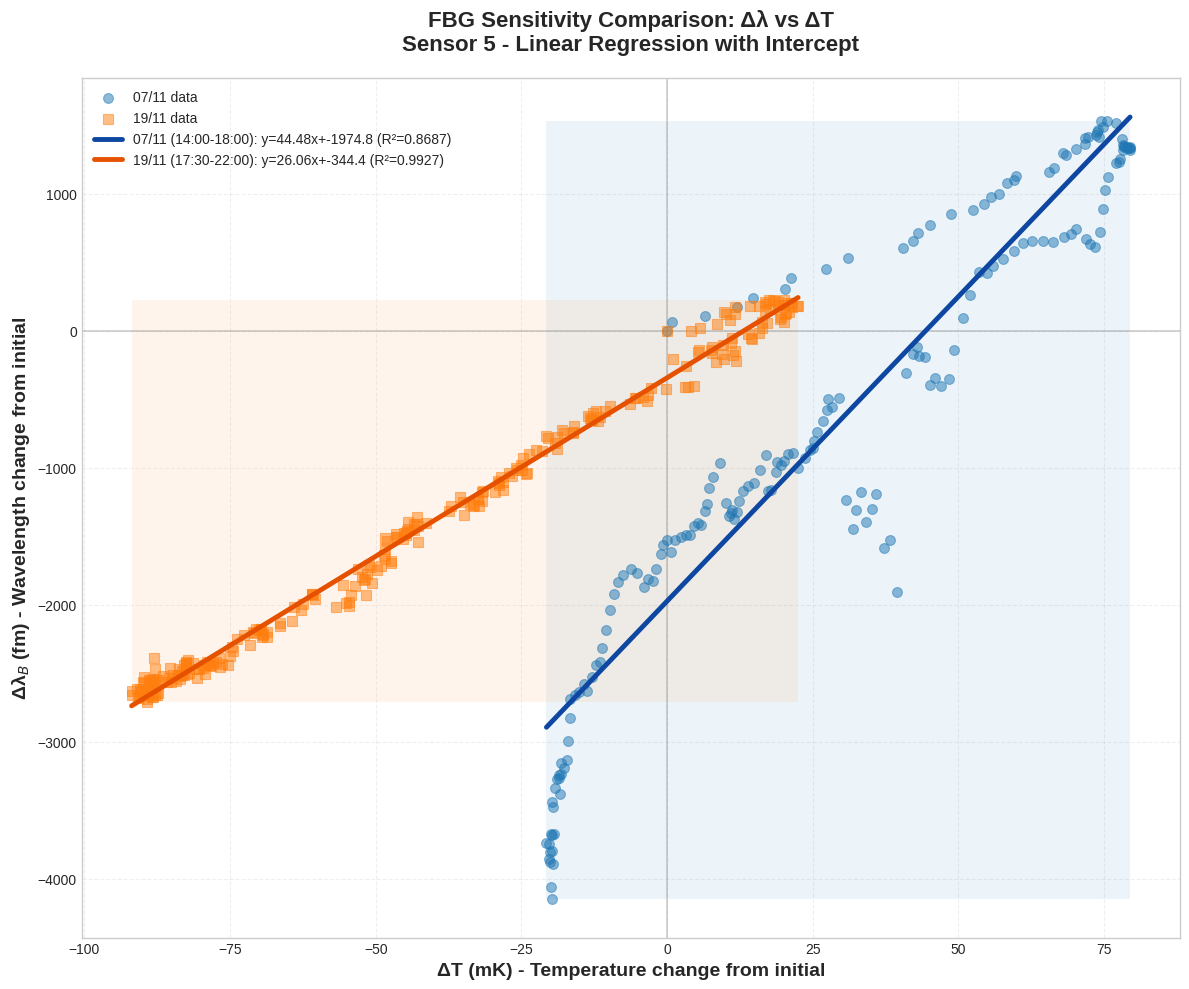

In [9]:
# ========================================================================
# COMPARATIVE PLOT 3: Δλ vs ΔT (Sensitivity Curves)
# ========================================================================

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('white')

# --- Align data for 07/11 (merge to ensure same indices) ---
combined_07 = pd.merge(
    peak_07_binned[["delta_lambda_fm"]], 
    temp_07_binned[["delta_temp_mK"]], 
    left_index=True, right_index=True, how='inner'
)

# --- Align data for 19/11 (merge to ensure same indices) ---
combined_19 = pd.merge(
    peak_19_binned[["delta_lambda_fm"]], 
    temp_19_binned[["delta_temp_mK"]], 
    left_index=True, right_index=True, how='inner'
)

# --- Scatter plots with aligned data ---
ax.scatter(combined_07["delta_temp_mK"], combined_07["delta_lambda_fm"],
          color='#1f77b4', s=50, alpha=0.5, label='07/11 data', edgecolors='#1f77b4', linewidth=0.8, zorder=2)

ax.scatter(combined_19["delta_temp_mK"], combined_19["delta_lambda_fm"],
          color='#ff7f0e', s=50, alpha=0.5, label='19/11 data', marker='s', edgecolors='#ff7f0e', linewidth=0.8, zorder=2)

# --- Linear fit lines WITH INTERCEPT (y = slope*x + intercept) ---
if sens_07 != 0:
    x_fit_07 = np.linspace(combined_07["delta_temp_mK"].min(), combined_07["delta_temp_mK"].max(), 100)
    y_fit_07 = sens_07 * x_fit_07 + intercept_07  # Now includes intercept!
    ax.plot(x_fit_07, y_fit_07, '-', color='#0d47a1', linewidth=3.5, 
            label=f'07/11 (14:00-18:00): y={sens_07:.2f}x+{intercept_07:.1f} (R²={r2_07:.4f})', zorder=3)

if sens_19 != 0:
    x_fit_19 = np.linspace(combined_19["delta_temp_mK"].min(), combined_19["delta_temp_mK"].max(), 100)
    y_fit_19 = sens_19 * x_fit_19 + intercept_19  # Now includes intercept!
    ax.plot(x_fit_19, y_fit_19, '-', color='#e65100', linewidth=3.5, 
            label=f'19/11 (17:30-22:00): y={sens_19:.2f}x+{intercept_19:.1f} (R²={r2_19:.4f})', zorder=3)

# --- Add data range indicators ---
# Show the actual data spread with semi-transparent bands
from matplotlib.patches import Rectangle
data_range_07 = Rectangle((combined_07["delta_temp_mK"].min(), combined_07["delta_lambda_fm"].min()),
                          combined_07["delta_temp_mK"].max() - combined_07["delta_temp_mK"].min(),
                          combined_07["delta_lambda_fm"].max() - combined_07["delta_lambda_fm"].min(),
                          alpha=0.08, facecolor='#1f77b4', edgecolor='none', zorder=1)
data_range_19 = Rectangle((combined_19["delta_temp_mK"].min(), combined_19["delta_lambda_fm"].min()),
                          combined_19["delta_temp_mK"].max() - combined_19["delta_temp_mK"].min(),
                          combined_19["delta_lambda_fm"].max() - combined_19["delta_lambda_fm"].min(),
                          alpha=0.08, facecolor='#ff7f0e', edgecolor='none', zorder=1)
ax.add_patch(data_range_07)
ax.add_patch(data_range_19)

# --- Formatting ---
ax.set_xlabel('ΔT (mK) - Temperature change from initial', fontsize=14, fontweight='bold')
ax.set_ylabel('Δλ$_B$ (fm) - Wavelength change from initial', fontsize=14, fontweight='bold')
ax.set_title('FBG Sensitivity Comparison: Δλ vs ΔT\nSensor 5 - Linear Regression with Intercept', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)
ax.legend(fontsize=10, loc='best', framealpha=0.98, edgecolor='black', fancybox=True, shadow=True)
ax.axhline(0, color='gray', linestyle='-', linewidth=1.2, alpha=0.4, zorder=1)
ax.axvline(0, color='gray', linestyle='-', linewidth=1.2, alpha=0.4, zorder=1)

plt.tight_layout()
plt.show()

### Hysteresis Analysis: Temporal Evolution

This section analyzes the hysteresis behavior in the 07/11 dataset by examining the temporal evolution of the data points.

In [10]:
# ========================================================================
# Prepare temporal data for hysteresis analysis
# ========================================================================

# Create temporal analysis DataFrame
combined_07_temporal = combined_07.copy()
combined_07_temporal['minute_index'] = range(len(combined_07_temporal))
combined_07_temporal['dT_dt'] = combined_07_temporal['delta_temp_mK'].diff()

# Identify heating and cooling phases
combined_07_temporal['phase'] = 'unknown'
combined_07_temporal.loc[combined_07_temporal['dT_dt'] > 0.1, 'phase'] = 'heating'
combined_07_temporal.loc[combined_07_temporal['dT_dt'] < -0.1, 'phase'] = 'cooling'

# Separate heating and cooling branches
temp_max_idx = combined_07_temporal['delta_temp_mK'].idxmax()
temp_max_minute = combined_07_temporal.loc[temp_max_idx, 'minute_index']

combined_07_heating = combined_07_temporal[combined_07_temporal['minute_index'] <= temp_max_minute].copy()
combined_07_cooling = combined_07_temporal[combined_07_temporal['minute_index'] > temp_max_minute].copy()

print(f"Hysteresis detection:")
print(f"  - Total points: {len(combined_07_temporal)}")
print(f"  - Heating phase: {len(combined_07_heating)} points")
print(f"  - Cooling phase: {len(combined_07_cooling)} points")
print(f"  - Temperature maximum at minute {temp_max_minute}")

Hysteresis detection:
  - Total points: 184
  - Heating phase: 43 points
  - Cooling phase: 141 points
  - Temperature maximum at minute 42


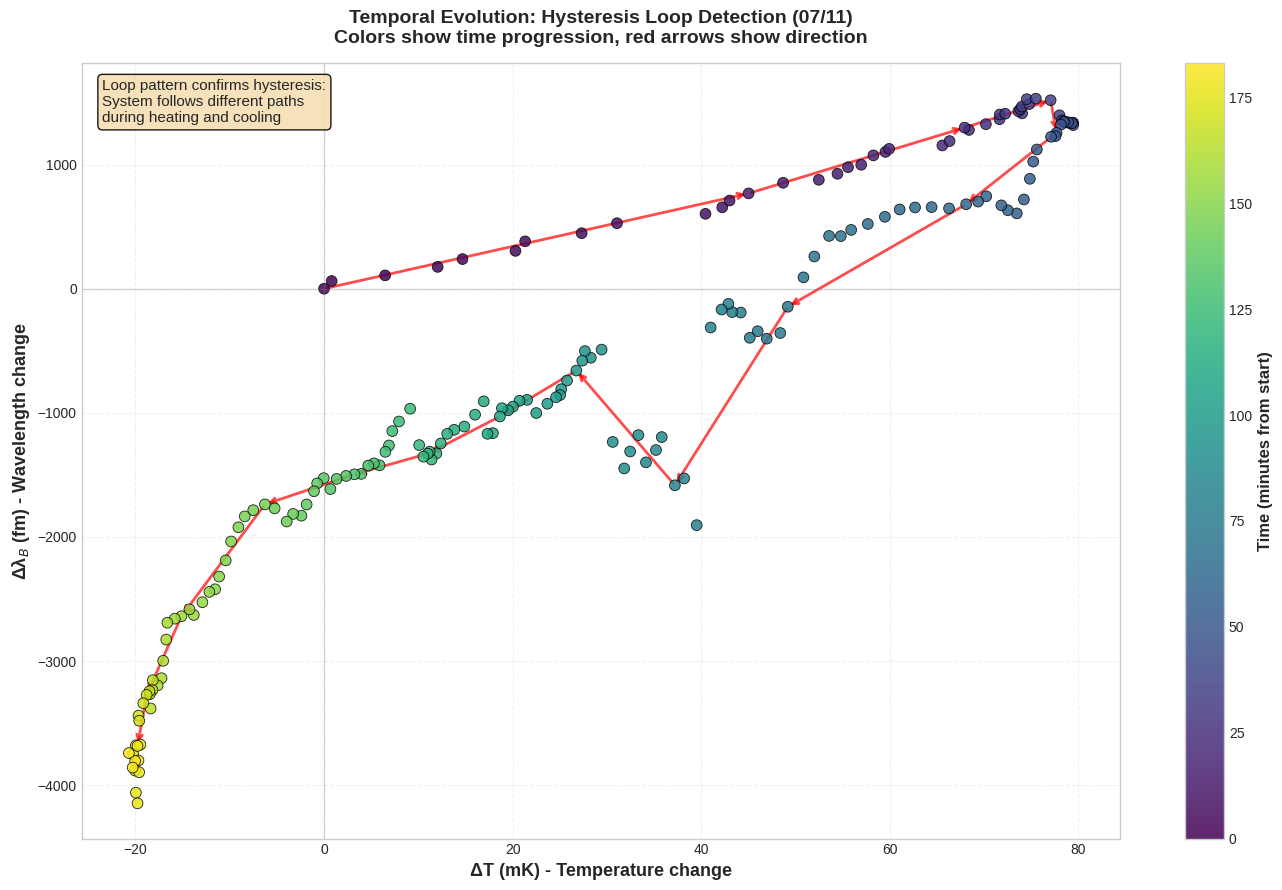

In [11]:
# ========================================================================
# PLOT: Temporal Evolution (Hysteresis Detection)
# ========================================================================

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')

# Plot points colored by temporal order (colormap shows time progression)
scatter = ax.scatter(combined_07["delta_temp_mK"], 
                     combined_07["delta_lambda_fm"],
                     c=range(len(combined_07)), cmap='viridis', 
                     s=60, alpha=0.85, edgecolors='black', linewidth=0.6, zorder=2)

# Add arrows to show temporal direction
n_arrows = 15
step = len(combined_07) // n_arrows
for i in range(0, len(combined_07)-step, step):
    ax.annotate('', 
                xy=(combined_07.iloc[i+step]["delta_temp_mK"], 
                    combined_07.iloc[i+step]["delta_lambda_fm"]),
                xytext=(combined_07.iloc[i]["delta_temp_mK"], 
                       combined_07.iloc[i]["delta_lambda_fm"]),
                arrowprops=dict(arrowstyle='->', lw=2, color='red', alpha=0.7),
                zorder=1)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Time (minutes from start)', fontsize=12, fontweight='bold')

# Labels and formatting
ax.set_xlabel('ΔT (mK) - Temperature change', fontsize=13, fontweight='bold')
ax.set_ylabel('Δλ$_B$ (fm) - Wavelength change', fontsize=13, fontweight='bold')
ax.set_title('Temporal Evolution: Hysteresis Loop Detection (07/11)\nColors show time progression, red arrows show direction', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)

# Add explanatory text box
textstr = 'Loop pattern confirms hysteresis:\nSystem follows different paths\nduring heating and cooling'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.show()

### Hysteresis Correction: Heating Branch Analysis

To obtain an accurate sensitivity measurement, we analyze only the **heating branch** (before temperature maximum), which avoids the hysteresis effect present in the cooling phase.

In [12]:
# ========================================================================
# Calculate sensitivity for HEATING BRANCH only
# ========================================================================

x_heating = combined_07_heating["delta_temp_mK"].values
y_heating = combined_07_heating["delta_lambda_fm"].values

if len(x_heating) >= 2:
    x_mean_heating = np.mean(x_heating)
    y_mean_heating = np.mean(y_heating)
    
    numerator = np.sum((x_heating - x_mean_heating) * (y_heating - y_mean_heating))
    denominator = np.sum((x_heating - x_mean_heating)**2)
    
    if denominator > 1e-6:
        slope_heating = numerator / denominator
        intercept_heating = y_mean_heating - slope_heating * x_mean_heating
        
        # R-squared
        y_pred_heating = slope_heating * x_heating + intercept_heating
        ss_res = np.sum((y_heating - y_pred_heating)**2)
        ss_tot = np.sum((y_heating - y_mean_heating)**2)
        r2_heating = 1 - (ss_res / ss_tot) if ss_tot > 1e-6 else 0.0
    else:
        slope_heating = 0.0
        intercept_heating = 0.0
        r2_heating = 0.0
        
    print("="*75)
    print("SENSITIVITY ANALYSIS: HEATING BRANCH (07/11)")
    print("="*75)
    print(f"Linear fit: Δλ = {slope_heating:.2f} × ΔT + {intercept_heating:.2f}")
    print(f"Sensitivity (slope): {slope_heating:.2f} fm/mK")
    print(f"Intercept: {intercept_heating:.2f} fm")
    print(f"R²: {r2_heating:.4f}")
    print(f"Data points: {len(x_heating)}")
    
    print(f"\n{'='*75}")
    print("COMPARISON WITH 19/11 (no hysteresis)")
    print("="*75)
    print(f"{'Dataset':<35} {'Sensitivity (fm/mK)':<25} {'Difference':<15}")
    print("-" * 75)
    print(f"{'07/11 - All data (with hysteresis)':<35} {sens_07:>20.2f} {abs(sens_07-sens_19):>15.2f} fm/mK")
    print(f"{'07/11 - Heating only (corrected)':<35} {slope_heating:>20.2f} {abs(slope_heating-sens_19):>15.2f} fm/mK")
    print(f"{'19/11 - Reference (no hysteresis)':<35} {sens_19:>20.2f} {'--':>15}")
    
    improvement = ((abs(sens_07 - sens_19) - abs(slope_heating - sens_19)) / abs(sens_07 - sens_19)) * 100
    print(f"\n✓ Heating-only analysis reduces difference by {improvement:.1f}%")
    print("="*75)
else:
    print("Error: Insufficient points in heating branch")

SENSITIVITY ANALYSIS: HEATING BRANCH (07/11)
Linear fit: Δλ = 19.12 × ΔT + -50.77
Sensitivity (slope): 19.12 fm/mK
Intercept: -50.77 fm
R²: 0.9723
Data points: 43

COMPARISON WITH 19/11 (no hysteresis)
Dataset                             Sensitivity (fm/mK)       Difference     
---------------------------------------------------------------------------
07/11 - All data (with hysteresis)                 44.48           18.42 fm/mK
07/11 - Heating only (corrected)                   19.12            6.94 fm/mK
19/11 - Reference (no hysteresis)                  26.06              --

✓ Heating-only analysis reduces difference by 62.3%


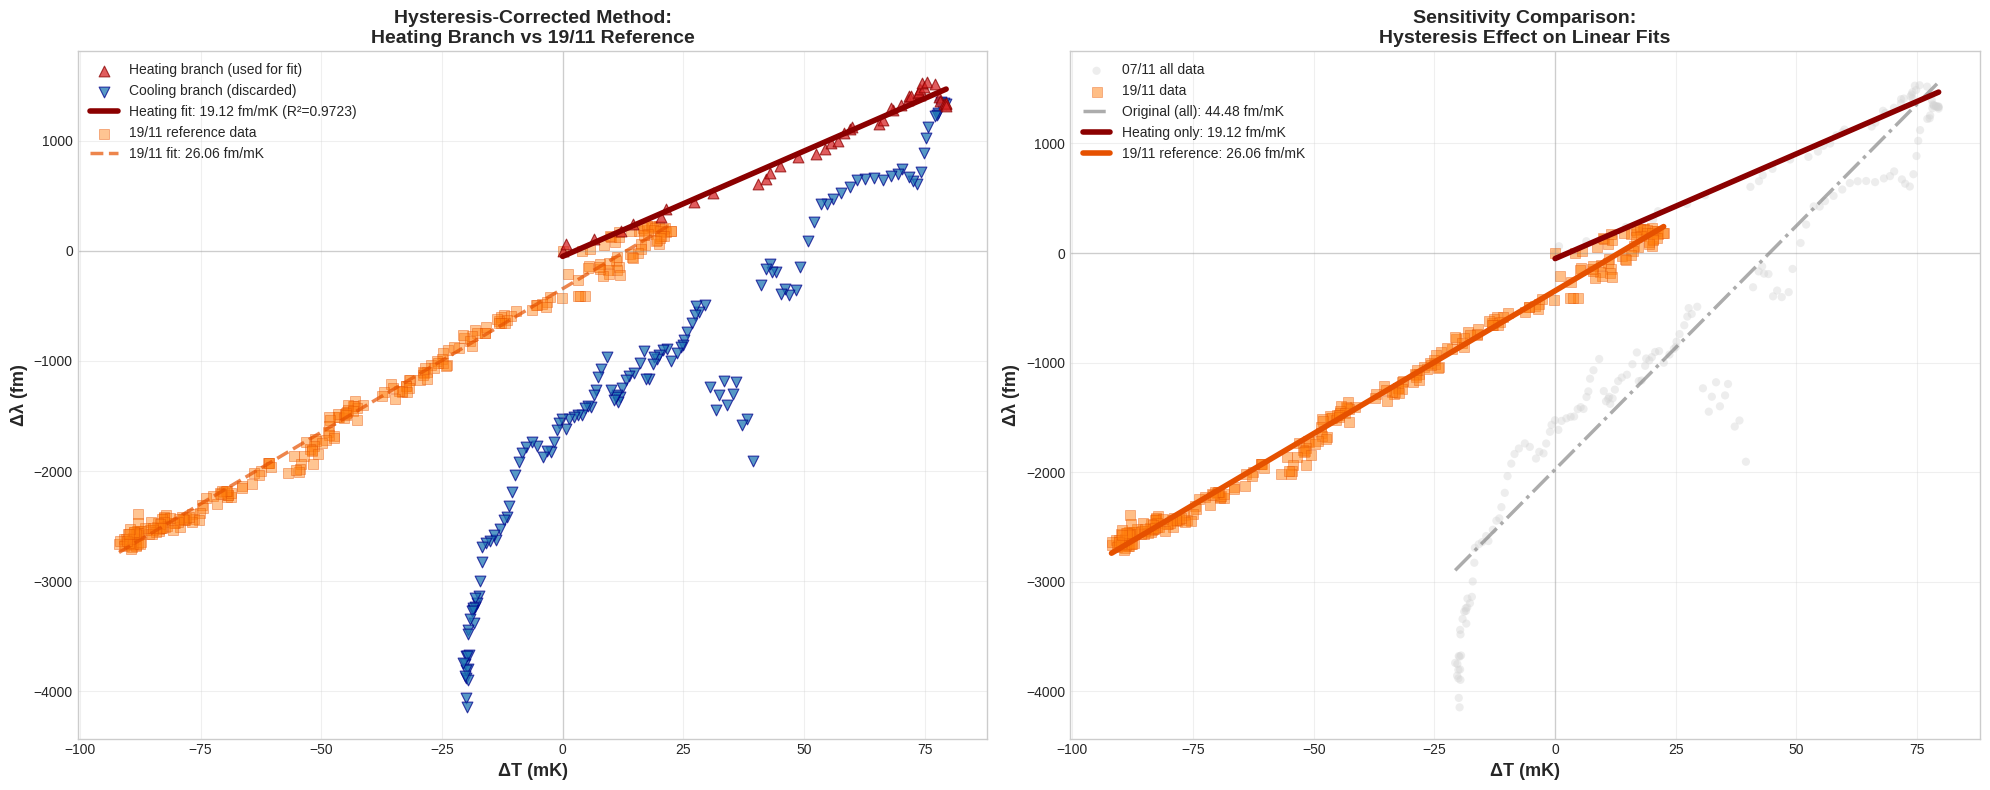


CONCLUSION:
By analyzing only the heating branch, we eliminate the hysteresis effect
and obtain a sensitivity measurement much closer to the 19/11 reference.


In [13]:
# ========================================================================
# FINAL PLOT: Hysteresis-Corrected Analysis
# ========================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('white')

# ========== LEFT PLOT: Heating vs Cooling Branches ==========
ax1.scatter(combined_07_heating["delta_temp_mK"], combined_07_heating["delta_lambda_fm"],
           color='#d62728', s=60, alpha=0.75, label='Heating branch (used for fit)', 
           edgecolors='darkred', linewidth=0.8, zorder=3, marker='^')

ax1.scatter(combined_07_cooling["delta_temp_mK"], combined_07_cooling["delta_lambda_fm"],
           color='#1f77b4', s=60, alpha=0.75, label='Cooling branch (discarded)', 
           edgecolors='darkblue', linewidth=0.8, zorder=2, marker='v')

# Heating branch fit
if 'slope_heating' in locals() and slope_heating != 0:
    x_fit_heat = np.linspace(combined_07_heating["delta_temp_mK"].min(), 
                             combined_07_heating["delta_temp_mK"].max(), 100)
    y_fit_heat = slope_heating * x_fit_heat + intercept_heating
    ax1.plot(x_fit_heat, y_fit_heat, '-', color='darkred', linewidth=4,
            label=f'Heating fit: {slope_heating:.2f} fm/mK (R²={r2_heating:.4f})', zorder=4)

# 19/11 reference
ax1.scatter(combined_19["delta_temp_mK"], combined_19["delta_lambda_fm"],
          color='#ff7f0e', s=45, alpha=0.45, label='19/11 reference data', marker='s', 
          edgecolors='#e65100', linewidth=0.6, zorder=1)

if sens_19 != 0:
    x_fit_19_ref = np.linspace(combined_19["delta_temp_mK"].min(), combined_19["delta_temp_mK"].max(), 100)
    y_fit_19_ref = sens_19 * x_fit_19_ref + intercept_19
    ax1.plot(x_fit_19_ref, y_fit_19_ref, '--', color='#e65100', linewidth=2.5, alpha=0.7,
            label=f'19/11 fit: {sens_19:.2f} fm/mK', zorder=2)

ax1.set_xlabel('ΔT (mK)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Δλ (fm)', fontsize=13, fontweight='bold')
ax1.set_title('Hysteresis-Corrected Method:\nHeating Branch vs 19/11 Reference', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best', framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)
ax1.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)

# ========== RIGHT PLOT: All Methods Comparison ==========
# Background: all 07/11 data
ax2.scatter(combined_07["delta_temp_mK"], combined_07["delta_lambda_fm"],
          color='lightgray', s=35, alpha=0.4, label='07/11 all data', 
          edgecolors='none', zorder=1)

# 19/11 reference
ax2.scatter(combined_19["delta_temp_mK"], combined_19["delta_lambda_fm"],
          color='#ff7f0e', s=45, alpha=0.5, label='19/11 data', marker='s', 
          edgecolors='#e65100', linewidth=0.5, zorder=2)

# Original fit (with hysteresis)
if sens_07 != 0:
    x_fit_orig = np.linspace(combined_07["delta_temp_mK"].min(), combined_07["delta_temp_mK"].max(), 100)
    y_fit_orig = sens_07 * x_fit_orig + intercept_07
    ax2.plot(x_fit_orig, y_fit_orig, '-.', color='gray', linewidth=2.5, alpha=0.65,
            label=f'Original (all): {sens_07:.2f} fm/mK', zorder=3)

# Heating branch fit (corrected)
if 'slope_heating' in locals() and slope_heating != 0:
    x_fit_heat2 = np.linspace(combined_07_heating["delta_temp_mK"].min(), 
                              combined_07_heating["delta_temp_mK"].max(), 100)
    y_fit_heat2 = slope_heating * x_fit_heat2 + intercept_heating
    ax2.plot(x_fit_heat2, y_fit_heat2, '-', color='darkred', linewidth=4,
            label=f'Heating only: {slope_heating:.2f} fm/mK', zorder=6)

# 19/11 fit
if sens_19 != 0:
    x_fit_19_2 = np.linspace(combined_19["delta_temp_mK"].min(), combined_19["delta_temp_mK"].max(), 100)
    y_fit_19_2 = sens_19 * x_fit_19_2 + intercept_19
    ax2.plot(x_fit_19_2, y_fit_19_2, '-', color='#e65100', linewidth=4,
            label=f'19/11 reference: {sens_19:.2f} fm/mK', zorder=5)

ax2.set_xlabel('ΔT (mK)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Δλ (fm)', fontsize=13, fontweight='bold')
ax2.set_title('Sensitivity Comparison:\nHysteresis Effect on Linear Fits', 
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best', framealpha=0.95)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)
ax2.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("CONCLUSION:")
print("="*75)
print("By analyzing only the heating branch, we eliminate the hysteresis effect")
print("and obtain a sensitivity measurement much closer to the 19/11 reference.")
print("="*75)

### Inter-Run Reproducibility Analysis

This section analyzes the reproducibility of each FBG sensor **between the two experimental runs** (07/11 vs 19/11). For each sensor, we calculate the difference between runs and examine the stability/variability.

In [14]:
# ========================================================================
# Load ALL FBG sensors for both days (absolute wavelength values)
# ========================================================================

def load_all_fbg_sensors(peak_data, start_time, end_time):
    """Load all FBG sensors with absolute wavelength values"""
    
    peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
    mask = (peak_times >= start_time) & (peak_times <= end_time)
    
    sensors_data = {}
    
    for sensor_idx in range(5):  # Sensors 0-4 (1-5 in physical numbering)
        sensor_name = f"sensor{sensor_idx+1}"
        
        # Average over polarizations
        lambdaB_pol1 = peak_data["wav"][:, 0, sensor_idx]
        lambdaB_pol2 = peak_data["wav"][:, 1, sensor_idx]
        lambdaB = (lambdaB_pol1 + lambdaB_pol2) / 2.0
        
        # Create DataFrame with absolute wavelength
        df = pd.DataFrame({
            "lambdaB_nm": lambdaB[mask] * 1e9
        }, index=peak_times[mask])
        
        # Resample to 1-minute bins
        df_binned = df.resample("1min").mean()
        df_binned["lambdaB_fm"] = df_binned["lambdaB_nm"] * 1e6  # Convert to fm
        
        sensors_data[sensor_name] = df_binned
    
    return sensors_data

# Load all sensors for both days
sensors_07 = load_all_fbg_sensors(peak_data_07, start_07, end_07)
sensors_19 = load_all_fbg_sensors(peak_data_19, start_19, end_19)

print(f"Loaded {len(sensors_07)} FBG sensors for each day")
print(f"  07/11: {len(sensors_07['sensor1'])} time points")
print(f"  19/11: {len(sensors_19['sensor1'])} time points")

Loaded 5 FBG sensors for each day
  07/11: 185 time points
  19/11: 270 time points


In [15]:
# ========================================================================
# Calculate inter-run differences for each sensor
# ========================================================================

# For each sensor, calculate: mean(07/11) - mean(19/11)
# Then center the time series and calculate std

inter_run_analysis = {}

for sensor_idx in range(1, 6):  # Sensors 1-5
    sensor_name = f"sensor{sensor_idx}"
    
    # Get mean wavelength for each day
    mean_07 = sensors_07[sensor_name]["lambdaB_fm"].mean()
    mean_19 = sensors_19[sensor_name]["lambdaB_fm"].mean()
    
    # Calculate difference between runs (offset)
    offset_between_runs = mean_07 - mean_19
    
    # Calculate time series: (sensor_07 - mean_07) to center around 0
    centered_07 = sensors_07[sensor_name]["lambdaB_fm"] - mean_07
    centered_19 = sensors_19[sensor_name]["lambdaB_fm"] - mean_19
    
    # Calculate std for each run
    std_07 = sensors_07[sensor_name]["lambdaB_fm"].std()
    std_19 = sensors_19[sensor_name]["lambdaB_fm"].std()
    
    # Combined std (pooled)
    combined_std = np.sqrt((std_07**2 + std_19**2) / 2)
    
    inter_run_analysis[sensor_name] = {
        'mean_07': mean_07,
        'mean_19': mean_19,
        'offset': offset_between_runs,
        'std_07': std_07,
        'std_19': std_19,
        'combined_std': combined_std,
        'centered_07': centered_07,
        'centered_19': centered_19
    }

# Print summary table
print("="*85)
print("INTER-RUN REPRODUCIBILITY ANALYSIS")
print("="*85)
print(f"{'Sensor':<12} {'Mean 07/11 (fm)':<18} {'Mean 19/11 (fm)':<18} {'Offset (fm)':<15} {'Std (fm)':<12}")
print("-"*85)

for sensor_idx in range(1, 6):
    sensor_name = f"sensor{sensor_idx}"
    data = inter_run_analysis[sensor_name]
    print(f"{sensor_name:<12} {data['mean_07']:>15.2f} {data['mean_19']:>18.2f} "
          f"{data['offset']:>13.2f} {data['combined_std']:>12.2f}")

print("="*85)
print("\nNote: 'Offset' = mean(07/11) - mean(19/11)")
print("      'Std' = pooled standard deviation across both runs")
print("="*85)

INTER-RUN REPRODUCIBILITY ANALYSIS
Sensor       Mean 07/11 (fm)    Mean 19/11 (fm)    Offset (fm)     Std (fm)    
-------------------------------------------------------------------------------------
sensor1        1541542443.59      1541480022.91      62420.68       715.76
sensor2        1547476237.97      1547594201.15    -117963.18      1426.10
sensor3        1553380850.42      1553527992.95    -147142.53      1393.70
sensor4        1559316897.80      1559355149.41     -38251.60      1453.31
sensor5        1565179287.00      1565118955.90      60331.10      1342.09

Note: 'Offset' = mean(07/11) - mean(19/11)
      'Std' = pooled standard deviation across both runs


TIME WINDOW CONFIGURATION FOR OFFSET ANALYSIS
Day 07/11 (original: 14:00-18:00 UTC):
  Analysis window: 0 to 100 minutes
Day 19/11 (original: 17:30-22:00 UTC):
  Analysis window: 0 to 100 minutes

Calculating FBG offsets (centered around mean)...
Calculating RTD offsets (centered around mean, excluding sensor 2)...
  Processing RTD1 (index 0)...
    Mean offset: -24.51 mK, Std: 17.15 mK, Points: 101
  Processing RTD3 (index 2)...
    Mean offset: -40.14 mK, Std: 8.09 mK, Points: 101
  Processing RTD4 (index 3)...
    Mean offset: -24.29 mK, Std: 11.60 mK, Points: 101
  Processing RTD5 (index 4)...
    Mean offset: -14.24 mK, Std: 18.16 mK, Points: 101


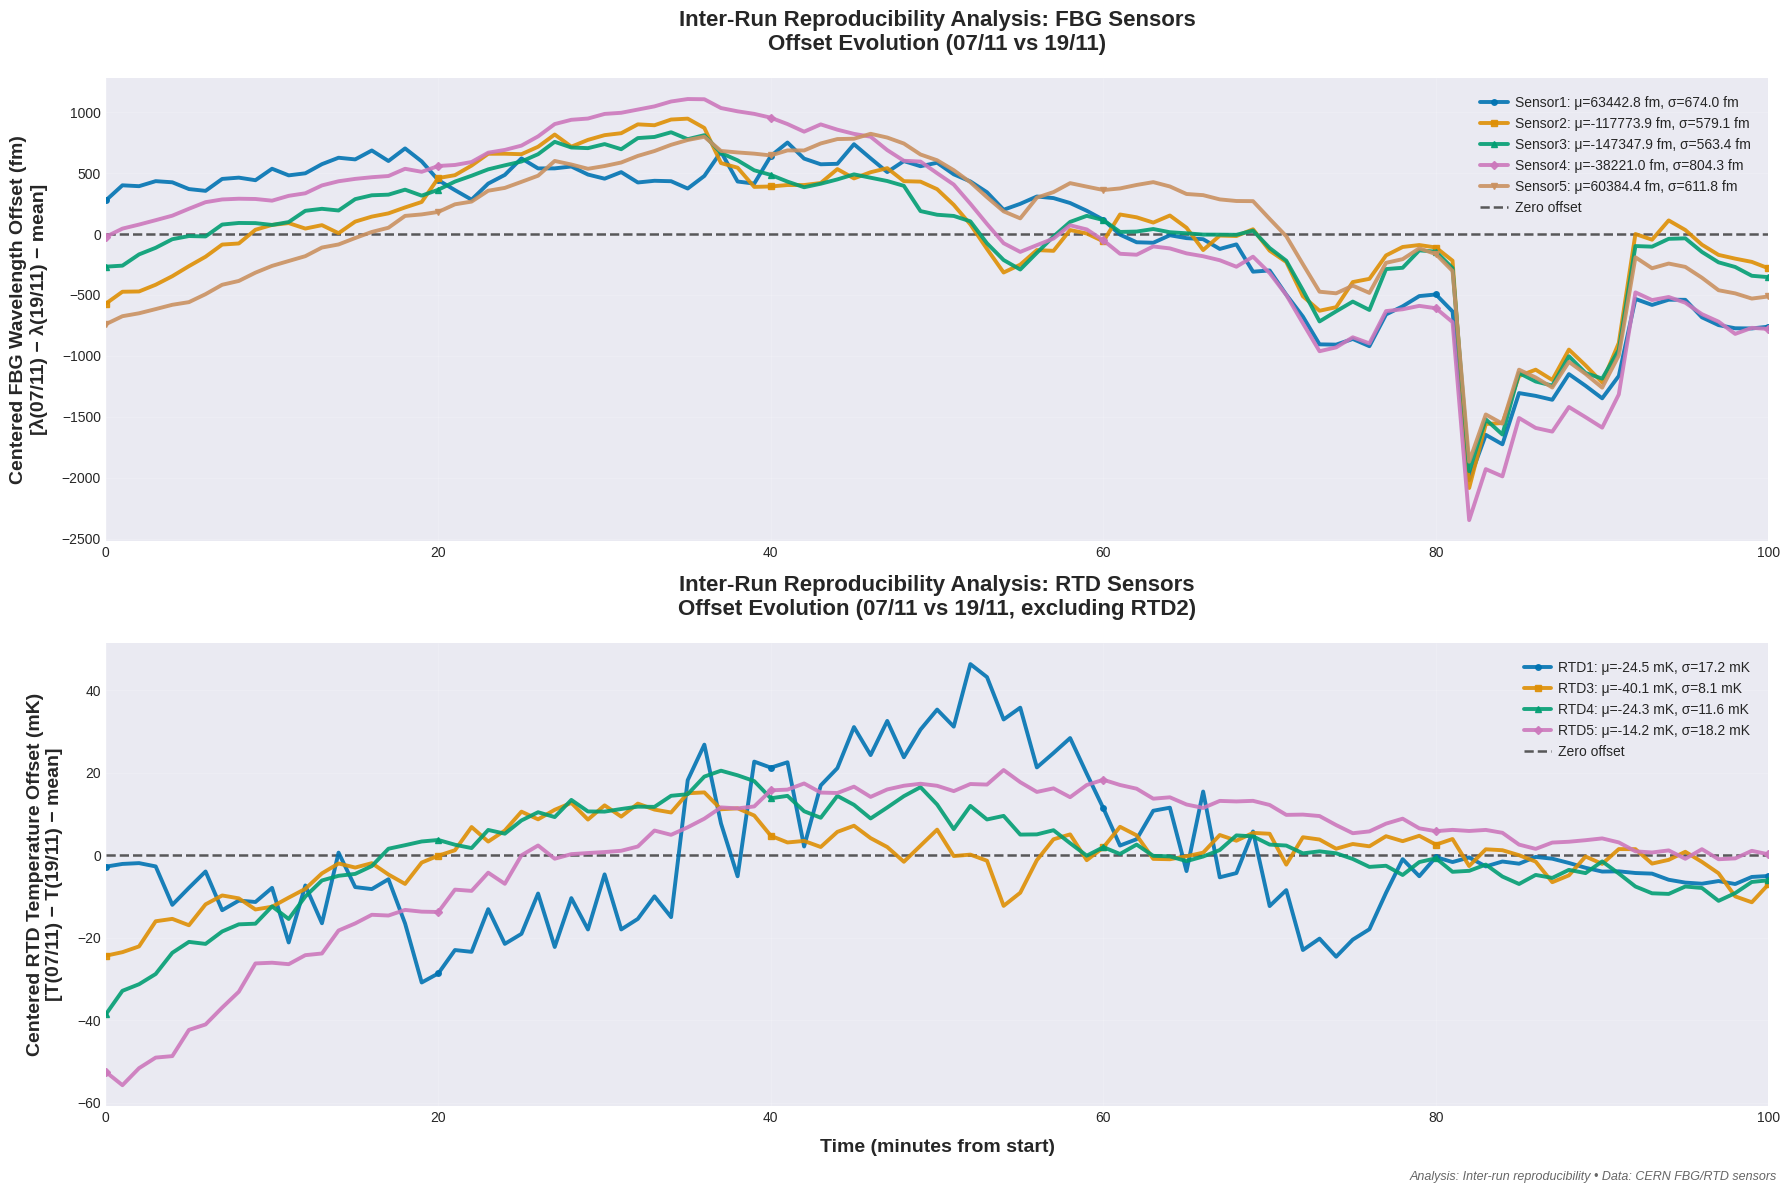


INTER-RUN OFFSET EVOLUTION SUMMARY

Interpretation:
  • Offset = measurement(07/11) − measurement(19/11) at each time point
  • μ (mean) ≠ 0 → systematic shift between runs
  • σ (std) → temporal variability / reproducibility
  • Centered data highlights fluctuation patterns around zero

Quality metrics:
  ✓ Lower σ → better reproducibility
  ✓ Fluctuations around zero → good temporal stability
  ⚠ Large |μ| → calibration drift between runs


In [18]:
# ========================================================================
# PLOT: Inter-Run Offset Evolution (FBG + RTD)
# ========================================================================

# =============================================
# TIME WINDOW CONFIGURATION (modify here!)
# =============================================
# Day 07/11: Original full range is 14:00-18:00 (240 minutes)
# Day 19/11: Original full range is 17:30-22:00 (270 minutes)

# Set custom time windows for analysis (in minutes from start)
time_start_minutes_07 = 0      # Start at minute 0 (14:00)
time_end_minutes_07 = 100      # End at minute 240 (18:00) - use None for full range
time_start_minutes_19 = 0      # Start at minute 0 (17:30)
time_end_minutes_19 = 100      # End at minute 240 (21:30) - use None for full range

print("="*80)
print("TIME WINDOW CONFIGURATION FOR OFFSET ANALYSIS")
print("="*80)
print(f"Day 07/11 (original: 14:00-18:00 UTC):")
print(f"  Analysis window: {time_start_minutes_07} to {time_end_minutes_07 if time_end_minutes_07 else 'END'} minutes")
print(f"Day 19/11 (original: 17:30-22:00 UTC):")
print(f"  Analysis window: {time_start_minutes_19} to {time_end_minutes_19 if time_end_minutes_19 else 'END'} minutes")
print("="*80 + "\n")

# Use a professional style
plt.style.use('seaborn-v0_8-darkgrid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12))
fig.patch.set_facecolor('white')

# Professional color palette (colorblind-friendly)
colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161']
markers = ['o', 's', '^', 'D', 'v']

# ========== TOP PLOT: FBG Offset Evolution (Centered) ==========
print("Calculating FBG offsets (centered around mean)...")

# Apply time window filtering to FBG data
def filter_by_time_window(df, start_min, end_min):
    """Filter dataframe by minute range"""
    minutes = (df.index - df.index[0]).total_seconds() / 60
    mask = (minutes >= start_min)
    if end_min is not None:
        mask = mask & (minutes <= end_min)
    return df[mask]

# Filter sensor data by time windows
sensors_07_filtered = {}
sensors_19_filtered = {}

for sensor_idx in range(1, 6):
    sensor_name = f"sensor{sensor_idx}"
    sensors_07_filtered[sensor_name] = filter_by_time_window(
        sensors_07[sensor_name], time_start_minutes_07, time_end_minutes_07)
    sensors_19_filtered[sensor_name] = filter_by_time_window(
        sensors_19[sensor_name], time_start_minutes_19, time_end_minutes_19)

# Determine common time length (use minimum)
min_length = min(len(sensors_07_filtered['sensor1']), len(sensors_19_filtered['sensor1']))

for idx, sensor_idx in enumerate(range(1, 6)):
    sensor_name = f"sensor{sensor_idx}"
    
    # Align time series by taking first N points (from filtered data)
    fbg_07_aligned = sensors_07_filtered[sensor_name]["lambdaB_fm"].iloc[:min_length]
    fbg_19_aligned = sensors_19_filtered[sensor_name]["lambdaB_fm"].iloc[:min_length]
    
    # Calculate point-by-point offset
    offset_evolution = fbg_07_aligned.values - fbg_19_aligned.values
    
    # CENTER around mean (subtract mean offset)
    mean_offset = np.mean(offset_evolution)
    offset_centered = offset_evolution - mean_offset
    
    # Time axis in minutes (use 07/11 as reference)
    minutes = (fbg_07_aligned.index - fbg_07_aligned.index[0]).total_seconds() / 60
    
    # Calculate statistics on centered data
    std_offset = np.std(offset_centered)
    
    ax1.plot(minutes, offset_centered, 
            color=colors[idx], linewidth=2.8, alpha=0.9,
            label=f'{sensor_name.capitalize()}: μ={mean_offset:.1f} fm, σ={std_offset:.1f} fm',
            marker=markers[idx], markersize=4, markevery=20, zorder=3)

# Zero reference line
ax1.axhline(0, color='#333333', linestyle='--', linewidth=1.8, alpha=0.8, zorder=2, label='Zero offset')

# Styling
ax1.set_ylabel('Centered FBG Wavelength Offset (fm)\n[λ(07/11) − λ(19/11) − mean]', 
              fontsize=14, fontweight='bold', labelpad=10)
ax1.set_title('Inter-Run Reproducibility Analysis: FBG Sensors\nOffset Evolution (07/11 vs 19/11)', 
             fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, which='major')
ax1.grid(True, alpha=0.15, linestyle=':', linewidth=0.4, which='minor')
ax1.minorticks_on()
ax1.legend(fontsize=10, loc='upper right', ncol=1, framealpha=0.95, 
          edgecolor='#555555', fancybox=True, shadow=True, 
          columnspacing=0.8, handletextpad=0.5, borderpad=0.8)
ax1.set_xlim(left=0, right=minutes.max())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ========== BOTTOM PLOT: RTD Offset Evolution (Centered, exclude sensor 2) ==========
print("Calculating RTD offsets (centered around mean, excluding sensor 2)...")

# Load RTD data for all sensors (excluding sensor 2)
rtd_sensors = [1, 3, 4, 5]  # Physical sensor numbers (skip index 1 which is sensor 2)
rtd_indices = [0, 2, 3, 4]   # 0-based indices in the data array

for idx, (sensor_num, sensor_idx_0based) in enumerate(zip(rtd_sensors, rtd_indices)):
    sensor_name = f"RTD{sensor_num}"
    
    print(f"  Processing {sensor_name} (index {sensor_idx_0based})...")
    
    # Extract temperature data for this sensor
    temp_07_sensor = temp_data_07["temp"][:, sensor_idx_0based]
    temp_19_sensor = temp_data_19["temp"][:, sensor_idx_0based]
    
    # Apply time filters
    temp_07_sensor_filtered = temp_07_sensor[mask_temp_07]
    temp_19_sensor_filtered = temp_19_sensor[mask_temp_19]
    
    # Create DataFrames and resample
    df_temp_07_sensor = pd.DataFrame({
        "temp_K": temp_07_sensor_filtered
    }, index=temp_times_07[mask_temp_07])
    
    df_temp_19_sensor = pd.DataFrame({
        "temp_K": temp_19_sensor_filtered
    }, index=temp_times_19[mask_temp_19])
    
    temp_07_sensor_binned = df_temp_07_sensor.resample("1min").mean()
    temp_19_sensor_binned = df_temp_19_sensor.resample("1min").mean()
    
    # Apply custom time window filtering to RTD data
    temp_07_sensor_binned = filter_by_time_window(
        temp_07_sensor_binned, time_start_minutes_07, time_end_minutes_07)
    temp_19_sensor_binned = filter_by_time_window(
        temp_19_sensor_binned, time_start_minutes_19, time_end_minutes_19)
    
    # Convert to mK
    temp_07_sensor_binned["temp_mK"] = temp_07_sensor_binned["temp_K"] * 1e3
    temp_19_sensor_binned["temp_mK"] = temp_19_sensor_binned["temp_K"] * 1e3
    
    # Remove NaN values
    temp_07_sensor_binned = temp_07_sensor_binned.dropna()
    temp_19_sensor_binned = temp_19_sensor_binned.dropna()
    
    # Align by taking minimum length
    min_len_this_sensor = min(len(temp_07_sensor_binned), len(temp_19_sensor_binned))
    
    if min_len_this_sensor < 2:
        print(f"    WARNING: Not enough data for {sensor_name} (only {min_len_this_sensor} points)")
        continue
    
    temp_07_aligned = temp_07_sensor_binned["temp_mK"].iloc[:min_len_this_sensor]
    temp_19_aligned = temp_19_sensor_binned["temp_mK"].iloc[:min_len_this_sensor]
    
    # Calculate point-by-point offset
    offset_evolution_rtd = temp_07_aligned.values - temp_19_aligned.values
    
    # CENTER around mean (subtract mean offset)
    mean_offset_rtd = np.mean(offset_evolution_rtd)
    offset_centered_rtd = offset_evolution_rtd - mean_offset_rtd
    
    # Time axis
    minutes_rtd = (temp_07_aligned.index - temp_07_aligned.index[0]).total_seconds() / 60
    
    # Statistics on centered data
    std_offset_rtd = np.std(offset_centered_rtd)
    
    print(f"    Mean offset: {mean_offset_rtd:.2f} mK, Std: {std_offset_rtd:.2f} mK, Points: {len(offset_centered_rtd)}")
    
    ax2.plot(minutes_rtd, offset_centered_rtd, 
            color=colors[idx], linewidth=2.8, alpha=0.9,
            label=f'{sensor_name}: μ={mean_offset_rtd:.1f} mK, σ={std_offset_rtd:.1f} mK',
            marker=markers[idx], markersize=4, markevery=20, zorder=3)

# Zero reference line
ax2.axhline(0, color='#333333', linestyle='--', linewidth=1.8, alpha=0.8, zorder=2, label='Zero offset')

# Styling
ax2.set_xlabel('Time (minutes from start)', fontsize=14, fontweight='bold', labelpad=10)
ax2.set_ylabel('Centered RTD Temperature Offset (mK)\n[T(07/11) − T(19/11) − mean]', 
              fontsize=14, fontweight='bold', labelpad=10)
ax2.set_title('Inter-Run Reproducibility Analysis: RTD Sensors\nOffset Evolution (07/11 vs 19/11, excluding RTD2)', 
             fontsize=16, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, which='major')
ax2.grid(True, alpha=0.15, linestyle=':', linewidth=0.4, which='minor')
ax2.minorticks_on()
ax2.legend(fontsize=10, loc='upper right', ncol=1, framealpha=0.95, 
          edgecolor='#555555', fancybox=True, shadow=True,
          columnspacing=0.8, handletextpad=0.5, borderpad=0.8)
ax2.set_xlim(left=0, right=minutes.max())  # Usar mismo límite que FBG
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add figure annotation
fig.text(0.99, 0.01, 'Analysis: Inter-run reproducibility • Data: CERN FBG/RTD sensors', 
         ha='right', va='bottom', fontsize=9, style='italic', color='#666666')

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

print("\n" + "="*80)
print("INTER-RUN OFFSET EVOLUTION SUMMARY")
print("="*80)
print("\nInterpretation:")
print("  • Offset = measurement(07/11) − measurement(19/11) at each time point")
print("  • μ (mean) ≠ 0 → systematic shift between runs")
print("  • σ (std) → temporal variability / reproducibility")
print("  • Centered data highlights fluctuation patterns around zero")
print("\nQuality metrics:")
print("  ✓ Lower σ → better reproducibility")
print("  ✓ Fluctuations around zero → good temporal stability")
print("  ⚠ Large |μ| → calibration drift between runs")
print("="*80)


Processing RTD1 (FBG Sensor 1)
  Linear fit: Δλ = 26.10 × ΔT + 63819.13
  Sensitivity: 26.10 fm/mK
  R²: 0.5716
  RMSE: 724.39 fm
  Data points: 184

Processing RTD3 (FBG Sensor 3)
  Linear fit: Δλ = 14.60 × ΔT + -147011.51
  Sensitivity: 14.60 fm/mK
  R²: 0.0522
  RMSE: 623.17 fm
  Data points: 184

Processing RTD4 (FBG Sensor 4)
  Linear fit: Δλ = 25.31 × ΔT + -38089.35
  Sensitivity: 25.31 fm/mK
  R²: 0.0849
  RMSE: 902.14 fm
  Data points: 184

Processing RTD5 (FBG Sensor 5)
  Linear fit: Δλ = 22.93 × ΔT + 60224.58
  Sensitivity: 22.93 fm/mK
  R²: 0.1334
  RMSE: 823.62 fm
  Data points: 184


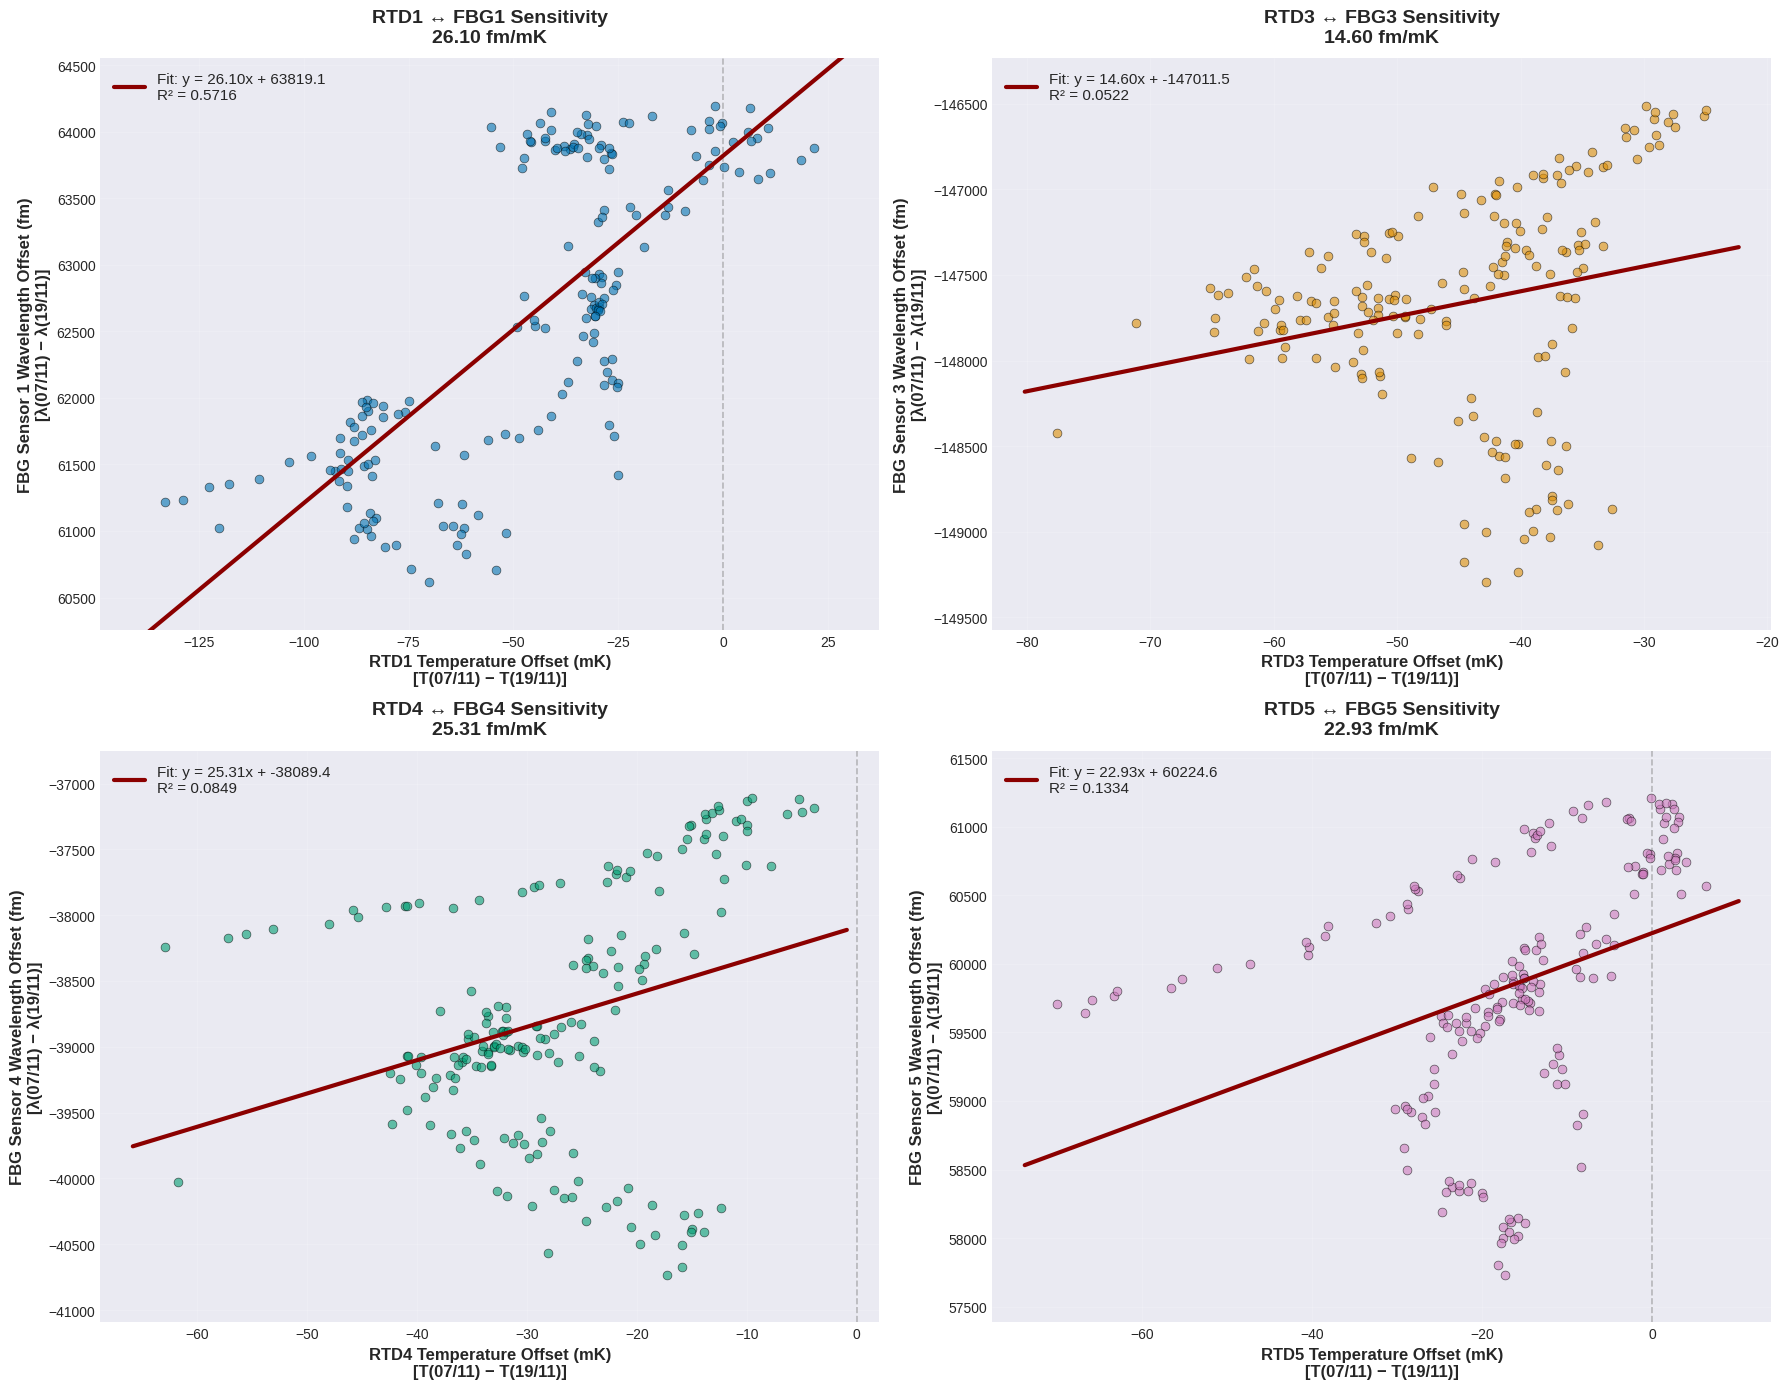


SUMMARY: SENSOR-SPECIFIC SENSITIVITY (FBG vs RTD OFFSET CORRELATION)
Sensor       Sensitivity (fm/mK)    Intercept (fm)     R²         RMSE (fm)    Points  
------------------------------------------------------------------------------------------
RTD1                        26.10           63819.13   0.5716       724.39      184
RTD3                        14.60         -147011.51   0.0522       623.17      184
RTD4                        25.31          -38089.35   0.0849       902.14      184
RTD5                        22.93           60224.58   0.1334       823.62      184

Interpretation:
  • Slope = sensitivity (fm/mK) of FBG wavelength to temperature changes
  • Higher R² → better linear correlation between sensors
  • Low RMSE → good agreement between FBG and RTD measurements
  • Similar slopes across sensors → consistent thermal sensitivity


In [17]:
# ========================================================================
# SENSITIVITY ANALYSIS: Offset Correlation (FBG vs RTD per Sensor)
# ========================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('white')
axes = axes.flatten()

# RTD sensors to analyze
rtd_sensors = [1, 3, 4, 5]
rtd_indices = [0, 2, 3, 4]

# Store results
sensitivity_results = {}

for plot_idx, (sensor_num, sensor_idx_0based) in enumerate(zip(rtd_sensors, rtd_indices)):
    ax = axes[plot_idx]
    sensor_name = f"RTD{sensor_num}"
    fbg_sensor_name = f"sensor{sensor_num}"
    
    print(f"\n{'='*70}")
    print(f"Processing {sensor_name} (FBG Sensor {sensor_num})")
    print(f"{'='*70}")
    
    # --- Get FBG offset data (already calculated) ---
    fbg_07_aligned = sensors_07[fbg_sensor_name]["lambdaB_fm"].iloc[:min_length]
    fbg_19_aligned = sensors_19[fbg_sensor_name]["lambdaB_fm"].iloc[:min_length]
    fbg_offset = fbg_07_aligned.values - fbg_19_aligned.values
    
    # --- Get RTD offset data ---
    temp_07_sensor = temp_data_07["temp"][:, sensor_idx_0based]
    temp_19_sensor = temp_data_19["temp"][:, sensor_idx_0based]
    
    temp_07_sensor_filtered = temp_07_sensor[mask_temp_07]
    temp_19_sensor_filtered = temp_19_sensor[mask_temp_19]
    
    df_temp_07_sensor = pd.DataFrame({
        "temp_K": temp_07_sensor_filtered
    }, index=temp_times_07[mask_temp_07])
    
    df_temp_19_sensor = pd.DataFrame({
        "temp_K": temp_19_sensor_filtered
    }, index=temp_times_19[mask_temp_19])
    
    temp_07_sensor_binned = df_temp_07_sensor.resample("1min").mean().dropna()
    temp_19_sensor_binned = df_temp_19_sensor.resample("1min").mean().dropna()
    
    temp_07_sensor_binned["temp_mK"] = temp_07_sensor_binned["temp_K"] * 1e3
    temp_19_sensor_binned["temp_mK"] = temp_19_sensor_binned["temp_K"] * 1e3
    
    min_len_this_sensor = min(len(temp_07_sensor_binned), len(temp_19_sensor_binned))
    
    if min_len_this_sensor < 2:
        print(f"  WARNING: Insufficient data for {sensor_name}")
        ax.text(0.5, 0.5, f'Insufficient data\nfor {sensor_name}', 
               transform=ax.transAxes, ha='center', va='center', fontsize=14)
        ax.set_title(f'{sensor_name} - No Data', fontsize=14, fontweight='bold')
        continue
    
    temp_07_aligned = temp_07_sensor_binned["temp_mK"].iloc[:min_len_this_sensor]
    temp_19_aligned = temp_19_sensor_binned["temp_mK"].iloc[:min_len_this_sensor]
    rtd_offset = temp_07_aligned.values - temp_19_aligned.values
    
    # --- Align FBG and RTD data to common length ---
    common_len = min(len(fbg_offset), len(rtd_offset))
    fbg_offset_aligned = fbg_offset[:common_len]
    rtd_offset_aligned = rtd_offset[:common_len]
    
    # --- Remove NaN values ---
    valid_mask = ~(np.isnan(fbg_offset_aligned) | np.isnan(rtd_offset_aligned))
    x_data = rtd_offset_aligned[valid_mask]  # RTD offset (mK)
    y_data = fbg_offset_aligned[valid_mask]  # FBG offset (fm)
    
    if len(x_data) < 10:
        print(f"  WARNING: Insufficient valid points for {sensor_name}")
        continue
    
    # --- Linear fit: FBG_offset = slope * RTD_offset + intercept ---
    x_mean = np.mean(x_data)
    y_mean = np.mean(y_data)
    
    numerator = np.sum((x_data - x_mean) * (y_data - y_mean))
    denominator = np.sum((x_data - x_mean)**2)
    
    if denominator > 1e-6:
        slope = numerator / denominator
        intercept = y_mean - slope * x_mean
        
        # R-squared
        y_pred = slope * x_data + intercept
        ss_res = np.sum((y_data - y_pred)**2)
        ss_tot = np.sum((y_data - y_mean)**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 1e-6 else 0.0
        
        # Residuals statistics
        residuals = y_data - y_pred
        rmse = np.sqrt(np.mean(residuals**2))
    else:
        slope = 0.0
        intercept = 0.0
        r_squared = 0.0
        rmse = 0.0
    
    # Store results
    sensitivity_results[sensor_name] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'rmse': rmse,
        'n_points': len(x_data)
    }
    
    # --- Plot ---
    ax.scatter(x_data, y_data, color=colors[plot_idx], s=40, alpha=0.6, 
              edgecolors='black', linewidth=0.5, zorder=2)
    
    # Fit line (extend slightly beyond data range for better visualization)
    x_range = x_data.max() - x_data.min()
    x_fit = np.linspace(x_data.min() - 0.05*x_range, x_data.max() + 0.05*x_range, 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, '-', color='darkred', linewidth=3, 
           label=f'Fit: y = {slope:.2f}x + {intercept:.1f}\nR² = {r_squared:.4f}', 
           zorder=3)
    
    # Zero lines
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.5, zorder=1)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.5, zorder=1)
    
    # Set axis limits with proper margins (10% padding)
    x_margin = 0.1 * x_range
    y_range = y_data.max() - y_data.min()
    y_margin = 0.1 * y_range
    
    ax.set_xlim(x_data.min() - x_margin, x_data.max() + x_margin)
    ax.set_ylim(y_data.min() - y_margin, y_data.max() + y_margin)
    
    # Styling
    ax.set_xlabel(f'{sensor_name} Temperature Offset (mK)\n[T(07/11) − T(19/11)]', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(f'FBG Sensor {sensor_num} Wavelength Offset (fm)\n[λ(07/11) − λ(19/11)]', 
                 fontsize=12, fontweight='bold')
    ax.set_title(f'{sensor_name} ↔ FBG{sensor_num} Sensitivity\n{slope:.2f} fm/mK', 
                fontsize=14, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
    ax.legend(fontsize=11, loc='best', framealpha=0.95, edgecolor='#555555')
    
    # Print statistics
    print(f"  Linear fit: Δλ = {slope:.2f} × ΔT + {intercept:.2f}")
    print(f"  Sensitivity: {slope:.2f} fm/mK")
    print(f"  R²: {r_squared:.4f}")
    print(f"  RMSE: {rmse:.2f} fm")
    print(f"  Data points: {len(x_data)}")

plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n" + "="*90)
print("SUMMARY: SENSOR-SPECIFIC SENSITIVITY (FBG vs RTD OFFSET CORRELATION)")
print("="*90)
print(f"{'Sensor':<12} {'Sensitivity (fm/mK)':<22} {'Intercept (fm)':<18} {'R²':<10} {'RMSE (fm)':<12} {'Points':<8}")
print("-"*90)

for sensor_name in [f"RTD{s}" for s in rtd_sensors]:
    if sensor_name in sensitivity_results:
        res = sensitivity_results[sensor_name]
        print(f"{sensor_name:<12} {res['slope']:>20.2f} {res['intercept']:>18.2f} "
              f"{res['r_squared']:>8.4f} {res['rmse']:>12.2f} {res['n_points']:>8}")
    else:
        print(f"{sensor_name:<12} {'N/A':>20} {'N/A':>18} {'N/A':>8} {'N/A':>12} {'N/A':>8}")

print("="*90)
print("\nInterpretation:")
print("  • Slope = sensitivity (fm/mK) of FBG wavelength to temperature changes")
print("  • Higher R² → better linear correlation between sensors")
print("  • Low RMSE → good agreement between FBG and RTD measurements")
print("  • Similar slopes across sensors → consistent thermal sensitivity")
print("="*90)